In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed


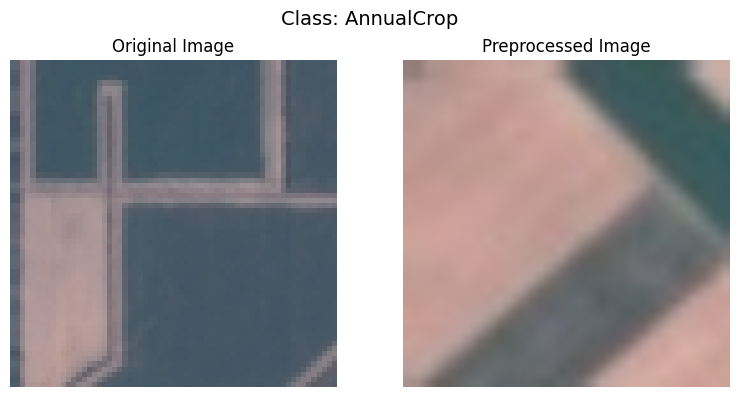

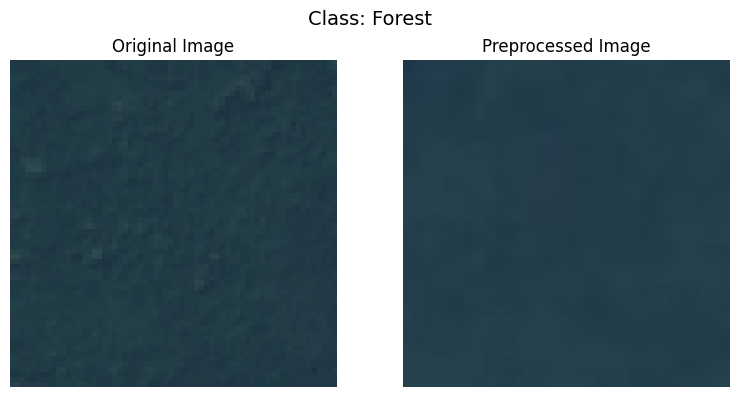

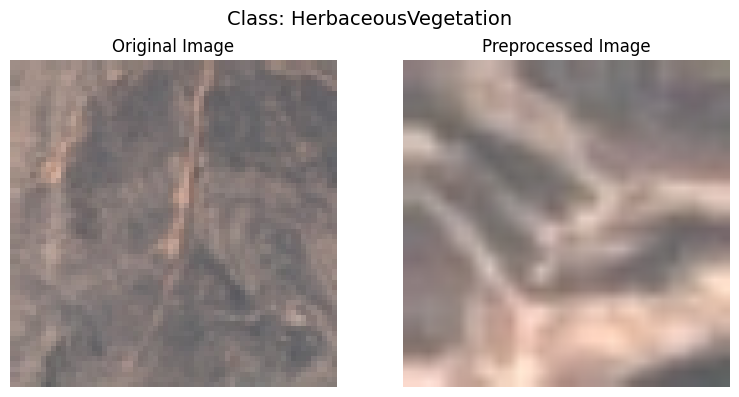

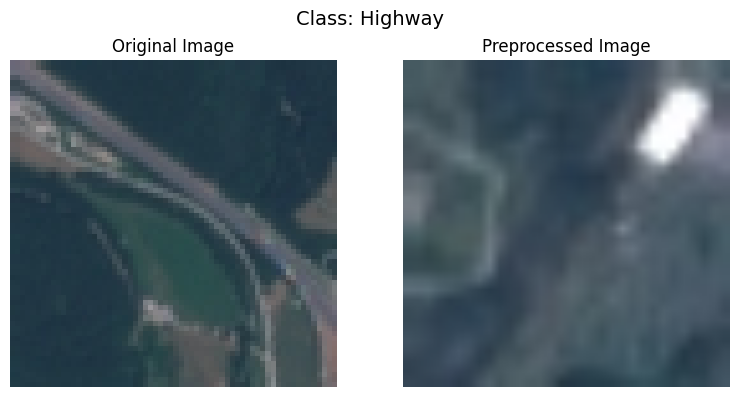

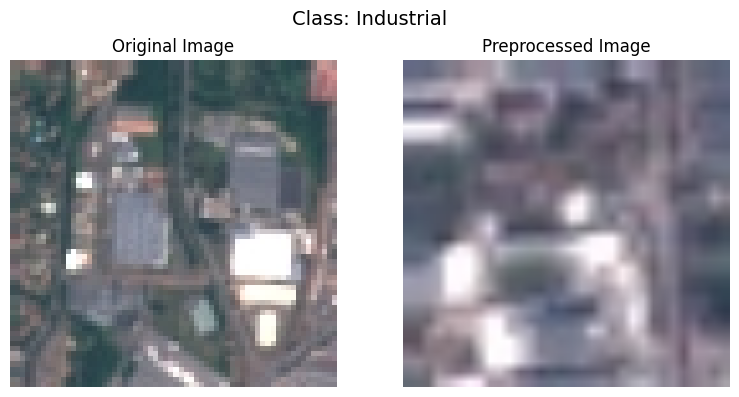

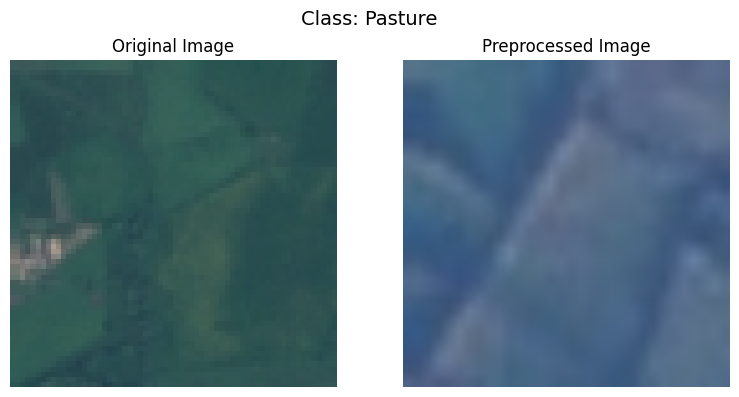

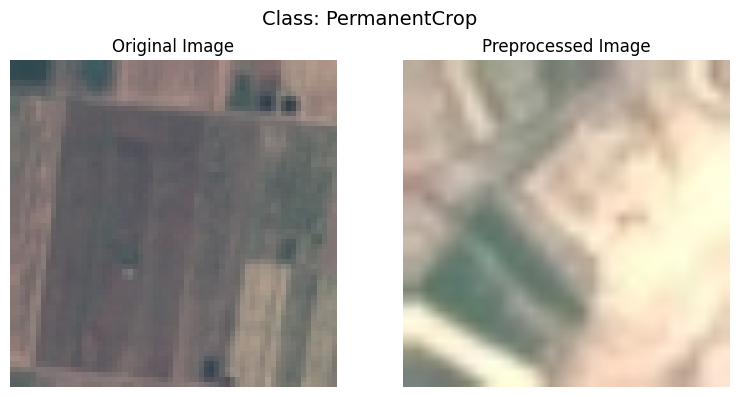

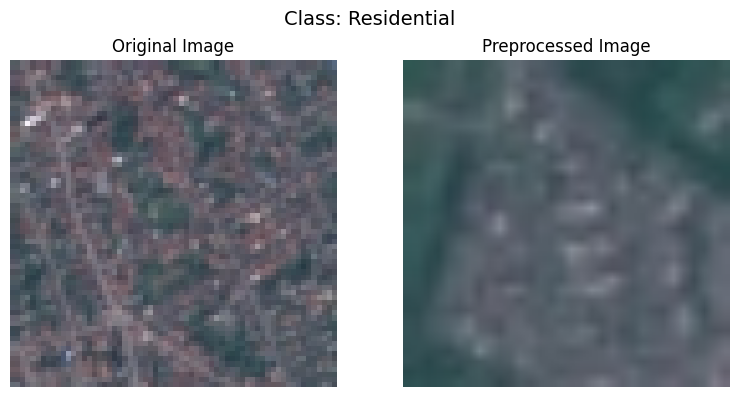

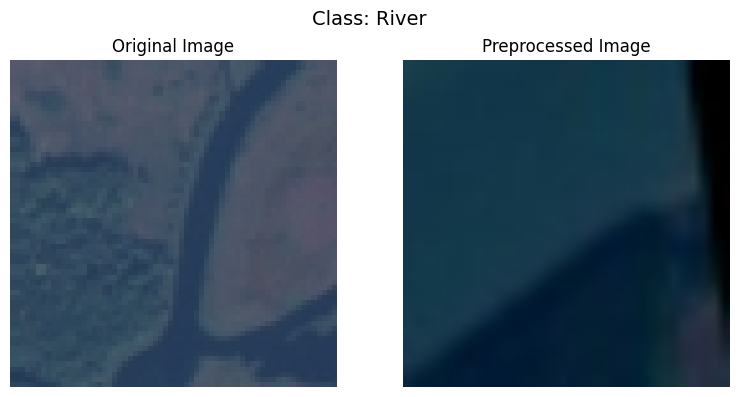

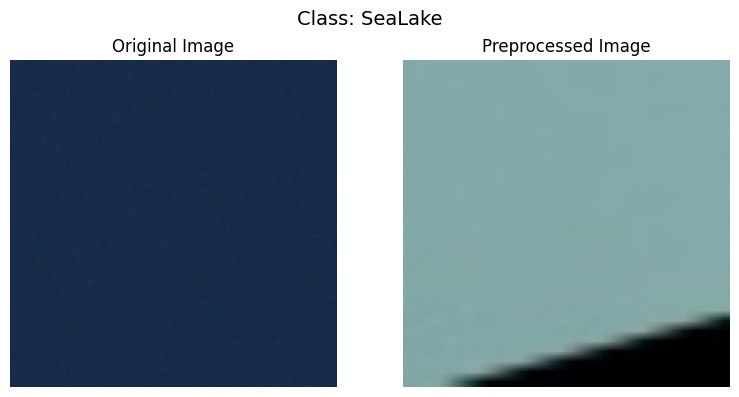

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torchvision import transforms

# Define paths
original_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
preprocessed_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"

# Define preprocessing transform
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Get all class folders
classes = sorted([cls for cls in os.listdir(original_dir) if os.path.isdir(os.path.join(original_dir, cls))])

# Display one image per class
for cls in classes:
    try:
        # Get image paths
        orig_img_path = os.path.join(original_dir, cls, os.listdir(os.path.join(original_dir, cls))[0])
        pre_img_path = os.path.join(preprocessed_dir, cls, os.listdir(os.path.join(preprocessed_dir, cls))[0])

        # Load images
        orig_img = Image.open(orig_img_path).convert("RGB")
        pre_img_raw = Image.open(pre_img_path).convert("RGB")

        # Apply preprocessing
        pre_img_tensor = preprocess(pre_img_raw)
        pre_img_np = pre_img_tensor.permute(1, 2, 0).numpy()
        pre_img_np = (pre_img_np * 0.5) + 0.5  # Unnormalize for display

        # Plotting
        plt.figure(figsize=(8, 4))
        plt.suptitle(f"Class: {cls}", fontsize=14)

        plt.subplot(1, 2, 1)
        plt.imshow(orig_img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(pre_img_np)
        plt.title("Preprocessed Image")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️ Error in class '{cls}': {e}")


In [ ]:
from torchvision import transforms
from PIL import Image

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=Image.LANCZOS),  # High-quality downsampling
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)        # Optional, for model input
])


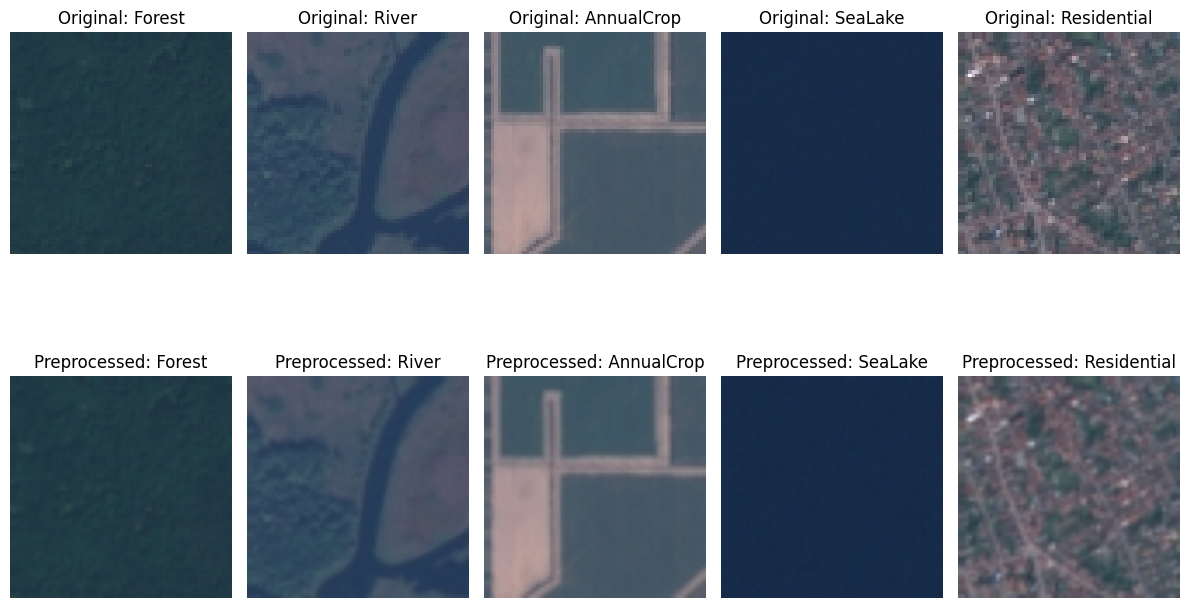

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# ✅ Update your dataset path here
base_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Select any 5 classes from your dataset
selected_classes = ['Forest', 'River', 'AnnualCrop', 'SeaLake', 'Residential']

# Define the preprocessing transformation
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

# Function to reverse normalization for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Plot original and preprocessed images
plt.figure(figsize=(12, 8))

for idx, cls in enumerate(selected_classes):
    class_path = os.path.join(base_dir, cls)
    image_name = os.listdir(class_path)[0]  # Take the first image from the class
    img_path = os.path.join(class_path, image_name)
    img = Image.open(img_path).convert('RGB')

    # Preprocess image
    processed_tensor = preprocess(img)

    # Convert tensor to image for display
    post_img = denormalize(processed_tensor).permute(1, 2, 0).numpy()

    # Display original
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(f"Original: {cls}")
    plt.axis('off')

    # Display preprocessed
    plt.subplot(2, 5, idx + 6)
    plt.imshow(post_img)
    plt.title(f"Preprocessed: {cls}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# Paths
input_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
output_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Preprocessing transformation
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Loop over all classes
classes = [cls for cls in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, cls))]

for cls in classes:
    input_class_path = os.path.join(input_dir, cls)
    output_class_path = os.path.join(output_dir, cls)
    os.makedirs(output_class_path, exist_ok=True)

    image_files = [f for f in os.listdir(input_class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for image_file in tqdm(image_files, desc=f"Processing {cls}"):
        input_path = os.path.join(input_class_path, image_file)
        output_path = os.path.join(output_class_path, image_file)

        try:
            img = Image.open(input_path).convert('RGB')
            processed = preprocess(img)

            # Convert back to image for saving (reverse normalization)
            unnormalized = processed.clone()
            unnormalized = unnormalized * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            unnormalized = unnormalized.clamp(0, 1)

            save_img = transforms.ToPILImage()(unnormalized)
            save_img.save(output_path)

        except Exception as e:
            print(f"Error processing {input_path}: {e}")

print("\n✅ All images preprocessed and saved to:", output_dir)


Processing AnnualCrop: 100%|██████████| 3010/3010 [03:06<00:00, 16.14it/s]


✅ All images preprocessed and saved to: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


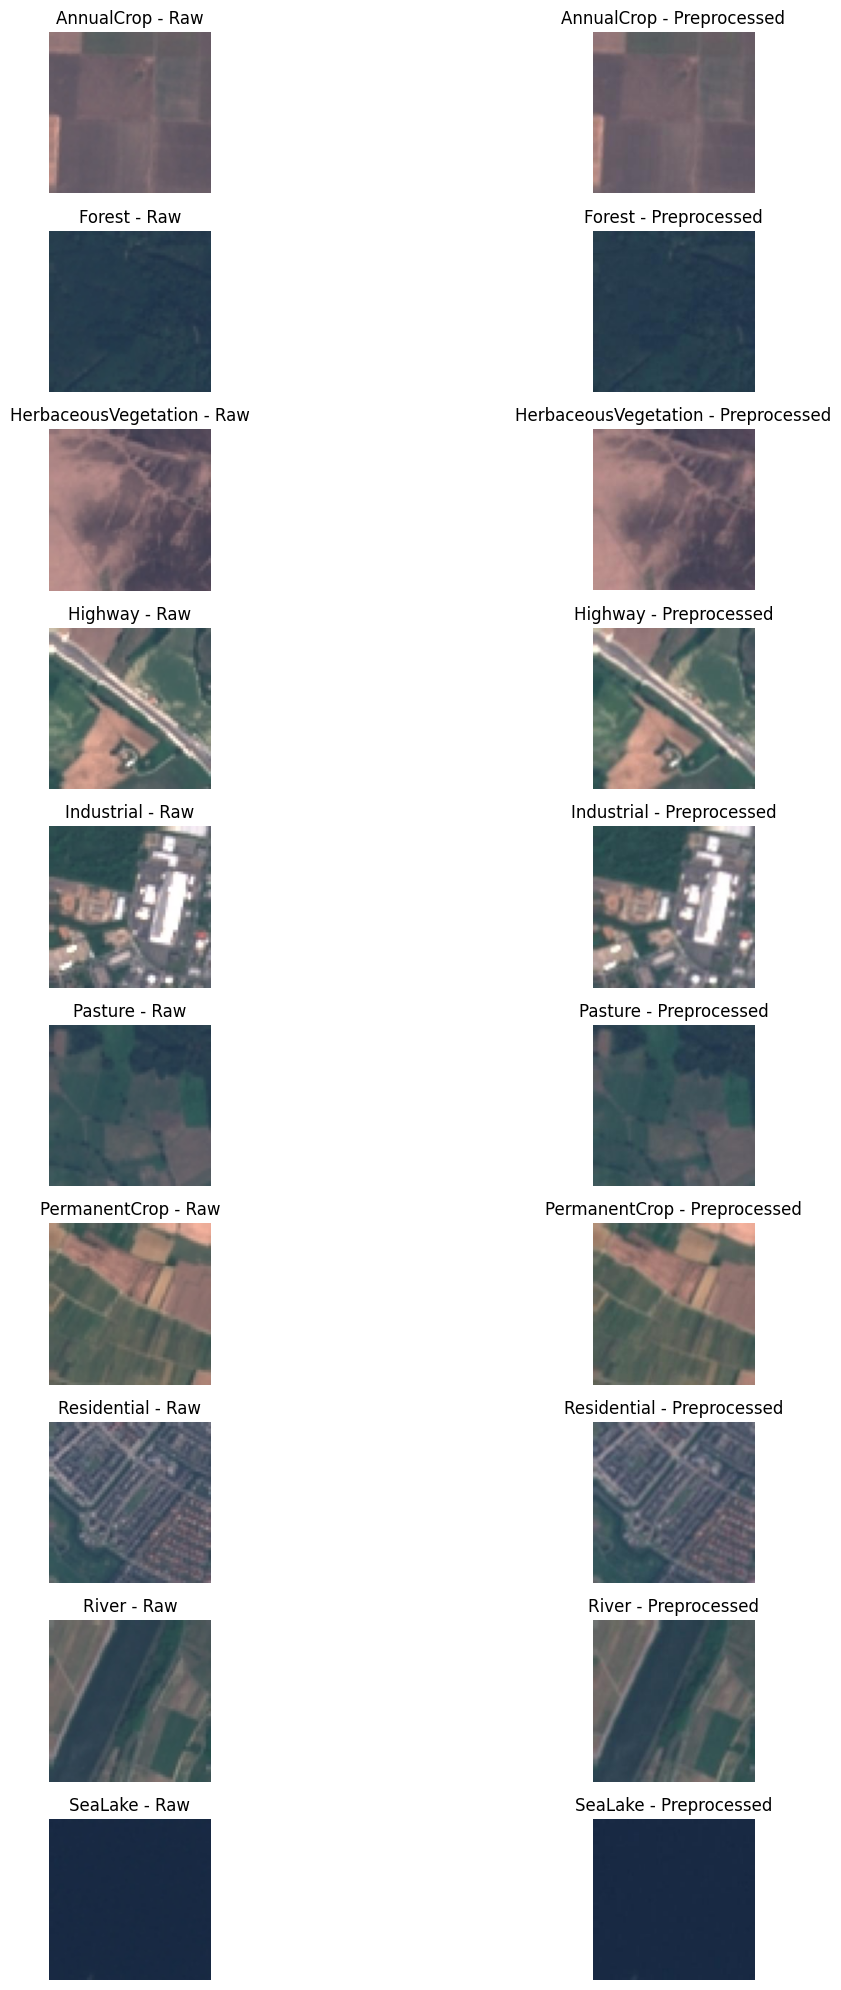

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Paths
raw_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
preprocessed_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# List of class names (you can limit to first 5 or show all 10)
classes = sorted(os.listdir(raw_dir))[:10]  # adjust [:5] to limit

# Plotting side-by-side comparisons
plt.figure(figsize=(15, 20))

for idx, cls in enumerate(classes):
    # Raw image
    raw_cls_path = os.path.join(raw_dir, cls)
    raw_img_path = os.path.join(raw_cls_path, sorted(os.listdir(raw_cls_path))[0])
    raw_img = Image.open(raw_img_path).convert('RGB')

    # Preprocessed image
    pre_cls_path = os.path.join(preprocessed_dir, cls)
    pre_img_path = os.path.join(pre_cls_path, sorted(os.listdir(pre_cls_path))[0])
    pre_img = Image.open(pre_img_path).convert('RGB')

    # Show raw
    plt.subplot(len(classes), 2, 2 * idx + 1)
    plt.imshow(raw_img)
    plt.title(f"{cls} - Raw")
    plt.axis("off")

    # Show preprocessed
    plt.subplot(len(classes), 2, 2 * idx + 2)
    plt.imshow(pre_img)
    plt.title(f"{cls} - Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Input preprocessed dataset
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
split_base = "/content/EuroSAT_full_split"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")

# Create folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Get class names
classes = sorted(os.listdir(source_dir))

# Split images for each class
for cls in tqdm(classes, desc="Splitting Classes"):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Split (80% train, 20% val)
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class folders
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # Copy train images
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    # Copy val images
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ All images split and saved to:", split_base)


Splitting Classes: 100%|██████████| 10/10 [08:48<00:00, 52.81s/it]

✅ All images split and saved to: /content/EuroSAT_full_split


In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load and use the YOLOv8 classification model
model = YOLO('yolov8n-cls.pt')

In [ ]:
yaml_content = """
path: /content/EuroSAT_full_split
train: train
val: val
nc: 10
names:
  - AnnualCrop
  - Forest
  - HerbaceousVegetation
  - Highway
  - Industrial
  - Pasture
  - PermanentCrop
  - Residential
  - River
  - SeaLake
"""

with open("eurosat_full.yaml", "w") as f:
    f.write(yaml_content)


In [ ]:
from ultralytics import YOLO

# Load the YOLOv8 classification model (nano version)
model = YOLO('yolov8n-cls.pt')

# Train directly using folders
model.train(
    data='/content/EuroSAT_full_split',
    epochs=3,
    imgsz=224,
    project='runs/classify',
    name='forest_cls50',
    pretrained=True
)


Ultralytics 8.3.164 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_full_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=forest_cls502, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

train: Scanning /content/EuroSAT_full_split/train... 21721 images, 0 corrupt: 100%|██████████| 21721/21721 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 113.1±34.8 MB/s, size: 3.3 KB)


val: Scanning /content/EuroSAT_full_split/val... 5432 images, 0 corrupt: 100%|██████████| 5432/5432 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 0 dataloader workers
Logging results to runs/classify/forest_cls502
Starting training for 3 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

                   all      0.956          1

3 epochs completed in 1.290 hours.


Optimizer stripped from runs/classify/forest_cls502/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/forest_cls502/weights/best.pt, 3.0MB

Validating runs/classify/forest_cls502/weights/best.pt...
Ultralytics 8.3.164 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_full_split/train... found 21721 images in 10 classes ✅ 
val: /content/EuroSAT_full_split/val... found 5432 images in 10 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 170/170 [01:40<00:00,  1.70it/s]


                   all      0.956          1
Speed: 0.0ms preprocess, 15.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/forest_cls502


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b688451e510>
curves: []
curves_results: []
fitness: 0.9780007302761078
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9563696384429932, 'metrics/accuracy_top5': 0.9996318221092224, 'fitness': 0.9780007302761078}
save_dir: PosixPath('runs/classify/forest_cls502')
speed: {'preprocess': 0.000969121319083058, 'inference': 15.912839535706825, 'loss': 6.728129776041929e-05, 'postprocess': 0.00017348784829675226}
task: 'classify'
top1: 0.9563696384429932
top5: 0.9996318221092224

In [ ]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Run validation to get metrics like accuracy, precision, recall, etc.
metrics = model.val(split='val')

# Show top-1 accuracy
print("✅ Top-1 Accuracy:", metrics.results_dict['metrics/accuracy_top1'])


Ultralytics 8.3.164 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_full_split/train... found 21721 images in 10 classes ✅ 
val: /content/EuroSAT_full_split/val... found 5432 images in 10 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 157.3±86.0 MB/s, size: 3.3 KB)


val: Scanning /content/EuroSAT_full_split/val... 5432 images, 0 corrupt: 100%|██████████| 5432/5432 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 340/340 [01:35<00:00,  3.56it/s]


                   all      0.957          1
Speed: 0.0ms preprocess, 15.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val
✅ Top-1 Accuracy: 0.9565537571907043


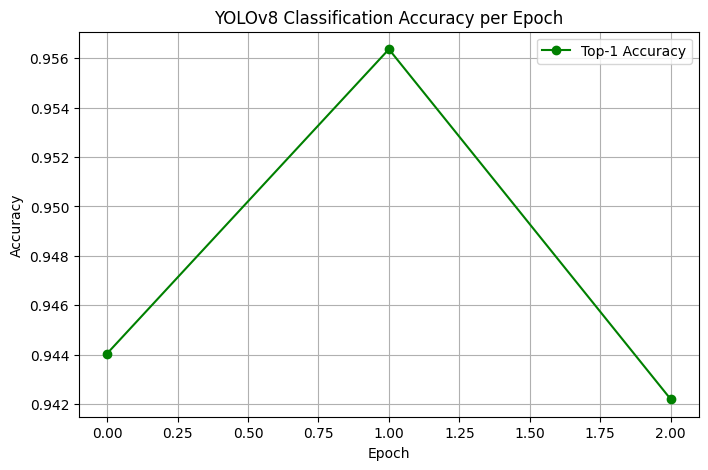

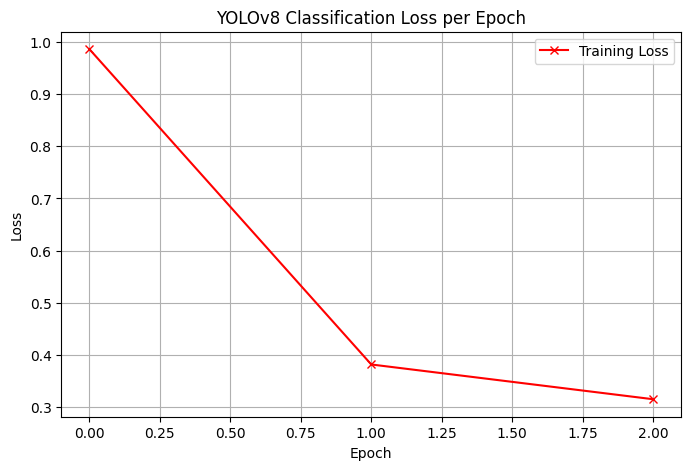

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results and clean column names
results_path = "runs/classify/forest_cls50/results.csv"
results_df = pd.read_csv(results_path)
results_df.columns = results_df.columns.str.strip()  # ✅ Remove leading/trailing spaces

# Plot Top-1 Accuracy
plt.figure(figsize=(8, 5))
plt.plot(results_df["metrics/accuracy_top1"], label="Top-1 Accuracy", color='green', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("YOLOv8 Classification Accuracy per Epoch")
plt.grid(True)
plt.legend()
plt.show()

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(results_df["train/loss"], label="Training Loss", color='red', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8 Classification Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()


Processing SeaLake: 100%|██████████| 602/602 [00:15<00:00, 37.81it/s]


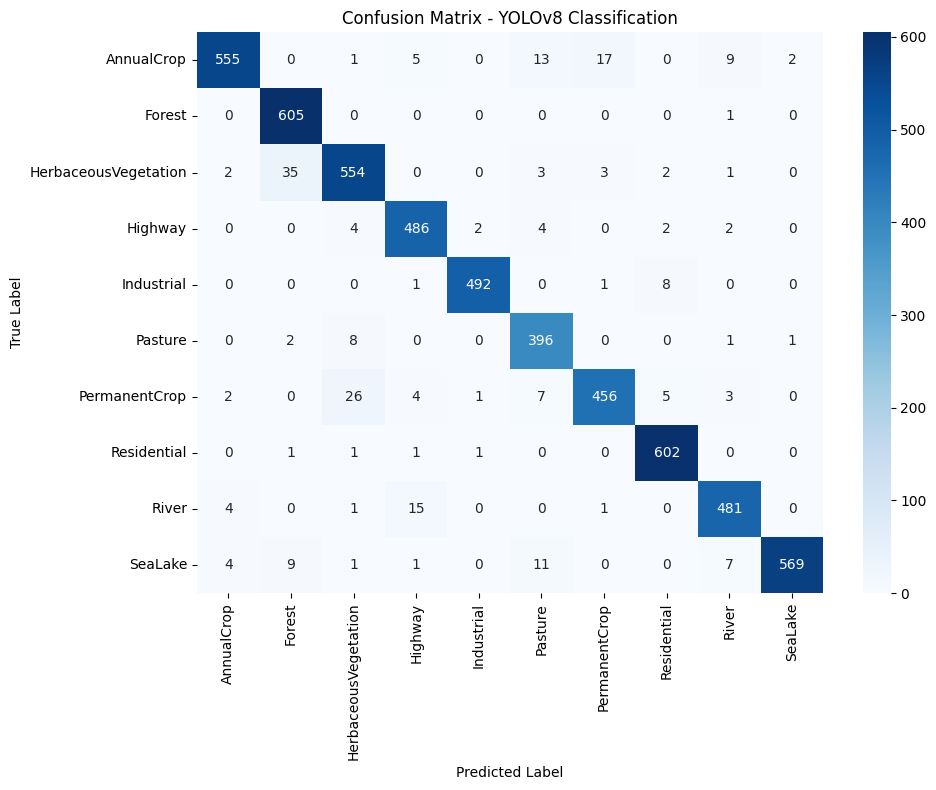

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO
from PIL import Image
from tqdm import tqdm

# Step 1: Load trained model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Step 2: Define validation directory
val_dir = "/content/EuroSAT_full_split/val"
classes = sorted(os.listdir(val_dir))

# Step 3: Collect true and predicted labels
true_labels = []
pred_labels = []

for class_index, class_name in enumerate(classes):
    class_path = os.path.join(val_dir, class_name)
    image_files = os.listdir(class_path)

    for image_name in tqdm(image_files, desc=f"Processing {class_name}"):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path).convert('RGB')
        result = model.predict(image, imgsz=224, verbose=False)[0]
        pred_class = int(result.probs.top1)

        true_labels.append(class_index)
        pred_labels.append(pred_class)

# Step 4: Generate Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLOv8 Classification")
plt.tight_layout()
plt.show()



0: 224x224 Forest 1.00, HerbaceousVegetation 0.00, SeaLake 0.00, Pasture 0.00, AnnualCrop 0.00, 111.8ms
Speed: 8.1ms preprocess, 111.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
✅ Predicted Class: Forest
🎯 Confidence: 99.61%


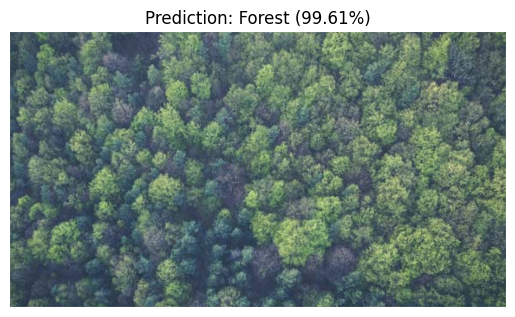

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Load trained YOLOv8 classification model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Path to your test image
img_path = "/content/drive/MyDrive/project/basepaper/forest11.jpg"

# Load and show the image
image = Image.open(img_path)

# Perform prediction
results = model(image)

# Extract prediction details
pred_label = results[0].probs.top1
pred_conf = results[0].probs.top1conf.item()
pred_class = model.names[pred_label]

# Print prediction info
print(f"✅ Predicted Class: {pred_class}")
print(f"🎯 Confidence: {pred_conf:.2%}")

# Plot the image with prediction title
plt.imshow(image)
plt.title(f"Prediction: {pred_class} ({pred_conf:.2%})")
plt.axis("off")
plt.show()



0: 224x224 AnnualCrop 0.52, Highway 0.47, PermanentCrop 0.01, River 0.01, SeaLake 0.00, 37.4ms
Speed: 8.6ms preprocess, 37.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
✅ Predicted Class: AnnualCrop
🎯 Confidence: 52.11%


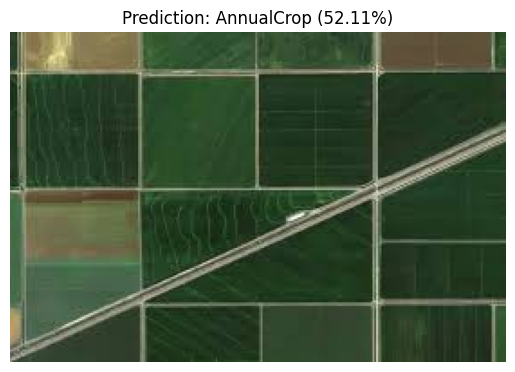

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Load trained YOLOv8 classification model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Path to your test image
img_path = "/content/drive/MyDrive/project/basepaper/t2.jpg"

# Load and show the image
image = Image.open(img_path)

# Perform prediction
results = model(image)

# Extract prediction details
pred_label = results[0].probs.top1
pred_conf = results[0].probs.top1conf.item()
pred_class = model.names[pred_label]

# Print prediction info
print(f"✅ Predicted Class: {pred_class}")
print(f"🎯 Confidence: {pred_conf:.2%}")

# Plot the image with prediction title
plt.imshow(image)
plt.title(f"Prediction: {pred_class} ({pred_conf:.2%})")
plt.axis("off")
plt.show()


In [ ]:
!pip install ultralytics --upgrade -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.3 MB/s eta 0:00:00


In [ ]:
data_dir = "/content/EuroSAT_full_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# ===== Configuration =====
data_dir = "/content/EuroSAT_full_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
batch_size = 16
num_epochs = 10
num_classes = len(os.listdir(train_dir))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Transforms =====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===== Dataset and Dataloaders =====
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
class_names = train_dataset.classes

# ===== Load EfficientNet-B0 =====
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# ===== Loss and Optimizer =====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ===== Training Loop =====
print("🔁 Training started...\n")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f}")

# ===== Evaluation =====
print("\n🧪 Evaluating on validation set...")
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.append(labels.item())
        y_pred.append(preds.cpu().item())

# ===== Classification Report =====
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ===== Confusion Matrix =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== Precision, Recall, F1 Bar Chart =====
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-Score', color='salmon')
plt.xticks(x, class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title(f"Per-Class Metrics (Overall Accuracy: {accuracy:.2%})")
plt.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/EuroSAT_full_split/train'